In [21]:

from langchain_groq import ChatGroq
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent
from langgraph.store.memory import InMemoryStore
from langgraph.utils.config import get_store
from langmem import create_manage_memory_tool

In [22]:
def prompt(state):
    store = get_store()
    memories = store.search(
        ("memories",),
        query=state["messages"][-1].content,
    )
    system_msg = f"""You are a helpful assistant.
## Memories
<memories>
{memories}
</memories>
"""
    return [{"role": "system", "content": system_msg}, *state["messages"]]


In [23]:
import os 
from dotenv import load_dotenv

_=load_dotenv()

embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
    google_api_key=os.environ.get("GOOGLE_API_KEY")
)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [24]:

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
)

In [25]:

store = InMemoryStore(
    index={
        "embed": embeddings,
        "dims": 3072,
    }
)


In [26]:
checkpointer = MemorySaver()

In [27]:
agent = create_react_agent(
    llm,
    prompt=prompt,
    tools=[create_manage_memory_tool(namespace=("memories",))],
    store=store,
    checkpointer=checkpointer,
)


/var/folders/4d/gf6xkqsd5tx6m_zltry403dc0000gn/T/ipykernel_91961/1852420494.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


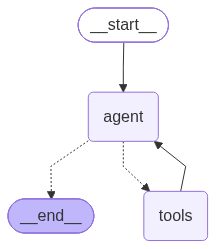

In [28]:
agent

In [29]:
config = {"configurable": {"thread_id": "thread-a"}}

In [30]:
# response = agent.invoke(
#     {
#         "messages": [
#             {"role": "user", "content": "do you Know which display mode I prefer?"}
#         ]
#     },
#     config=config,
# )
# print(response["messages"][-1].content)

In [31]:
# agent.invoke(
#     {
#         "messages": [
#             {"role": "user", "content": "I prefer dark mode. Remember that."}
#         ]
#     },
#     config=config,
# )

In [32]:
# {'messages': [HumanMessage(content='do you Know which display mode I prefer?', additional_kwargs={}, response_metadata={}, id='f23d3ffb-69fc-4342-a3c3-5d6be8d1e830'),
#   AIMessage(content="I don't currently have access to your preferred display mode in this conversation. Would you like to specify your preferred display mode (e.g., dark mode, light mode, high contrast) so I can create a memory for it?", additional_kwargs={'reasoning_content': "Okay, the user is asking if I know their preferred display mode. Let me check my existing memories first. Since this is a new conversation, there are no memories listed. The user might be referring to a display mode they mentioned before, but since there's no memory available, I don't have that information.\n\nI need to respond that I don't have access to their previous preferences. But maybe they want to set a new preference now. I should ask them to specify their preferred display mode so I can create a memory for it. That way, in future interactions, I can use that information. Let me prompt them to provide the details so I can update my memory accordingly.\n"}, response_metadata={'token_usage': {'completion_tokens': 188, 'prompt_tokens': 338, 'total_tokens': 526, 'completion_time': 0.380115571, 'completion_tokens_details': {'reasoning_tokens': 137}, 'prompt_time': 0.013518772, 'prompt_tokens_details': None, 'queue_time': 0.157284217, 'total_time': 0.393634343}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc924-3afd-7130-bb0f-89832e4bea64-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 338, 'output_tokens': 188, 'total_tokens': 526, 'output_token_details': {'reasoning': 137}}),
#   HumanMessage(content='I prefer dark mode. Remember that.', additional_kwargs={}, response_metadata={}, id='2394304f-d316-4330-9c14-3932b58ef773'),
#   AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user just told me they prefer dark mode and wants me to remember that. Let me check the tools available. There\'s the manage_memory function. The description says to use it when creating, updating, or deleting a memory. Since the user is specifying a preference, I should create a new memory here. The parameters for create don\'t require an ID, so I\'ll omit that. The content should be "dark mode" and the action is create. Let me make sure I\'m using the right structure. The function expects a JSON object with action, content, and id. Since it\'s a create action, id is null. So the tool call should have action as "create", content as "dark mode", and id as null. That should persist the user\'s preference.\n', 'tool_calls': [{'id': 'jbtegfvc5', 'function': {'arguments': '{"action":"create","content":"User prefers dark mode","id":null}', 'name': 'manage_memory'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 198, 'prompt_tokens': 402, 'total_tokens': 600, 'completion_time': 0.536061132, 'completion_tokens_details': {'reasoning_tokens': 160}, 'prompt_time': 0.018627076, 'prompt_tokens_details': None, 'queue_time': 0.046574173, 'total_time': 0.554688208}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc924-d900-7f80-a2ca-264ced1d5cc5-0', tool_calls=[{'name': 'manage_memory', 'args': {'action': 'create', 'content': 'User prefers dark mode', 'id': None}, 'id': 'jbtegfvc5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 402, 'output_tokens': 198, 'total_tokens': 600, 'output_token_details': {'reasoning': 160}}),
#   ToolMessage(content='created memory 2d849c44-421e-4bfa-a88c-e17e76a808aa', name='manage_memory', id='457fe526-1a07-40f1-a0b7-8c5e3af6e697', tool_call_id='jbtegfvc5'),
#   AIMessage(content='Your preference for dark mode is already recorded in memory (ID: 2d849c44-421e-4bfa-a88c-e17e76a808aa). The interface will adjust accordingly. Is there anything else I can assist you with?', additional_kwargs={'reasoning_content': 'Okay, the user just told me they prefer dark mode and asked me to remember that. Let me check the memories provided. There\'s a memory with the content "User prefers dark mode" already existing. Wait, but in the initial memories, the score was 0.613, and the created and updated times were in 2026. That seems a bit in the future, maybe a typo? Anyway, the user is confirming their preference again.\n\nSince there\'s already a memory with that content, do I need to create a new one or update the existing one? The user said "Remember that," so I should ensure the memory is recorded. The function call earlier was to create a memory, but since it\'s already there, maybe I should update it? But the ID is provided in the memory, so perhaps I should use the update action with the existing ID. Wait, the user didn\'t mention the ID, but the system has it. As an assistant, when the user gives a preference, I can check if there\'s an existing memory. If there is, update it; if not, create a new one. In this case, there\'s an existing memory, so I should update it. But the user hasn\'t provided the ID, so maybe the system can handle it by using the content to find the memory. However, the function requires the ID for update. Hmm, the initial tool call was to create, and the response was a created memory with that ID. Now, since the user is reiterating the same preference, maybe I should just confirm and not make another tool call. Wait, the user\'s latest message is "I prefer dark. Remember that." and the previous interaction already created the memory. The assistant\'s last response was a tool call to create, and the system responded that it was created. Now, the user might expect a confirmation. So, I should inform the user that their preference is already recorded and maybe offer to update if they want. Wait, but the user is saying again, so maybe they want to confirm or maybe there was an error. Let me check the existing memory. The existing memory has the content "User prefers dark mode." The user now says "I prefer dark. Remember that." So, it\'s the same content. Therefore, the assistant should respond that it\'s already remembered and perhaps ask if they want to change it. Alternatively, since the user is reiterating, maybe they want to ensure it\'s saved. The assistant should confirm that the preference is already recorded. Since the tool call was already made and the memory exists, no further action is needed unless the user wants to change it. So, the response should be something like, "Your preference for dark mode is already recorded. Is there anything else I can assist you with?" But wait, the user\'s current input is "I prefer dark. Remember that." So, maybe they are correcting or adding again. Wait, in the previous messages, the user said "I prefer dark mode. Remember that." and the assistant created the memory. Now, maybe the user is testing or wants to ensure it\'s saved. The assistant should confirm that it\'s already saved. Therefore, no tool call is needed here because the memory already exists. The assistant should just respond with confirmation. However, looking back, in the initial memories, the content was "User prefers dark mode" with a UUID. The user\'s current input is "I prefer dark. Remember that." which is slightly different in wording ("dark" vs "dark mode"). But the meaning is the same. The assistant should recognize that and update the existing memory if necessary. However, since the content is slightly different, maybe the assistant should update it to match the user\'s exact wording. But the existing memory has "dark mode," and the user now says "dark." Should the assistant consider them the same? Probably yes. So, maybe the assistant should update the existing memory with the new content, but since the meaning is the same, it\'s not necessary. Alternatively, the assistant can confirm that the preference is already recorded. Therefore, the correct response is to inform the user that their preference is already remembered and offer further help. No tool call is needed here because the memory is already in place. The assistant should just respond naturally.\n'}, response_metadata={'token_usage': {'completion_tokens': 945, 'prompt_tokens': 628, 'total_tokens': 1573, 'completion_time': 2.17435397, 'completion_tokens_details': {'reasoning_tokens': 877}, 'prompt_time': 0.026347251, 'prompt_tokens_details': None, 'queue_time': 0.046410189, 'total_time': 2.200701221}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc924-df18-7ee2-828c-3dd764286bfc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 628, 'output_tokens': 945, 'total_tokens': 1573, 'output_token_details': {'reasoning': 877}})]}

In [33]:
# agent.invoke(
#     {
#         "messages": [
#             {"role": "user", "content": "what is my prefered diaplay mode"}
#         ]
#     },
#     config=config,
# )

In [34]:
# {'messages': [HumanMessage(content='do you Know which display mode I prefer?', additional_kwargs={}, response_metadata={}, id='f23d3ffb-69fc-4342-a3c3-5d6be8d1e830'),
#   AIMessage(content="I don't currently have access to your preferred display mode in this conversation. Would you like to specify your preferred display mode (e.g., dark mode, light mode, high contrast) so I can create a memory for it?", additional_kwargs={'reasoning_content': "Okay, the user is asking if I know their preferred display mode. Let me check my existing memories first. Since this is a new conversation, there are no memories listed. The user might be referring to a display mode they mentioned before, but since there's no memory available, I don't have that information.\n\nI need to respond that I don't have access to their previous preferences. But maybe they want to set a new preference now. I should ask them to specify their preferred display mode so I can create a memory for it. That way, in future interactions, I can use that information. Let me prompt them to provide the details so I can update my memory accordingly.\n"}, response_metadata={'token_usage': {'completion_tokens': 188, 'prompt_tokens': 338, 'total_tokens': 526, 'completion_time': 0.380115571, 'completion_tokens_details': {'reasoning_tokens': 137}, 'prompt_time': 0.013518772, 'prompt_tokens_details': None, 'queue_time': 0.157284217, 'total_time': 0.393634343}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc924-3afd-7130-bb0f-89832e4bea64-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 338, 'output_tokens': 188, 'total_tokens': 526, 'output_token_details': {'reasoning': 137}}),
#   HumanMessage(content='I prefer dark mode. Remember that.', additional_kwargs={}, response_metadata={}, id='2394304f-d316-4330-9c14-3932b58ef773'),
#   AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user just told me they prefer dark mode and wants me to remember that. Let me check the tools available. There\'s the manage_memory function. The description says to use it when creating, updating, or deleting a memory. Since the user is specifying a preference, I should create a new memory here. The parameters for create don\'t require an ID, so I\'ll omit that. The content should be "dark mode" and the action is create. Let me make sure I\'m using the right structure. The function expects a JSON object with action, content, and id. Since it\'s a create action, id is null. So the tool call should have action as "create", content as "dark mode", and id as null. That should persist the user\'s preference.\n', 'tool_calls': [{'id': 'jbtegfvc5', 'function': {'arguments': '{"action":"create","content":"User prefers dark mode","id":null}', 'name': 'manage_memory'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 198, 'prompt_tokens': 402, 'total_tokens': 600, 'completion_time': 0.536061132, 'completion_tokens_details': {'reasoning_tokens': 160}, 'prompt_time': 0.018627076, 'prompt_tokens_details': None, 'queue_time': 0.046574173, 'total_time': 0.554688208}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc924-d900-7f80-a2ca-264ced1d5cc5-0', tool_calls=[{'name': 'manage_memory', 'args': {'action': 'create', 'content': 'User prefers dark mode', 'id': None}, 'id': 'jbtegfvc5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 402, 'output_tokens': 198, 'total_tokens': 600, 'output_token_details': {'reasoning': 160}}),
#   ToolMessage(content='created memory 2d849c44-421e-4bfa-a88c-e17e76a808aa', name='manage_memory', id='457fe526-1a07-40f1-a0b7-8c5e3af6e697', tool_call_id='jbtegfvc5'),
#   AIMessage(content='Your preference for dark mode is already recorded in memory (ID: 2d849c44-421e-4bfa-a88c-e17e76a808aa). The interface will adjust accordingly. Is there anything else I can assist you with?', additional_kwargs={'reasoning_content': 'Okay, the user just told me they prefer dark mode and asked me to remember that. Let me check the memories provided. There\'s a memory with the content "User prefers dark mode" already existing. Wait, but in the initial memories, the score was 0.613, and the created and updated times were in 2026. That seems a bit in the future, maybe a typo? Anyway, the user is confirming their preference again.\n\nSince there\'s already a memory with that content, do I need to create a new one or update the existing one? The user said "Remember that," so I should ensure the memory is recorded. The function call earlier was to create a memory, but since it\'s already there, maybe I should update it? But the ID is provided in the memory, so perhaps I should use the update action with the existing ID. Wait, the user didn\'t mention the ID, but the system has it. As an assistant, when the user gives a preference, I can check if there\'s an existing memory. If there is, update it; if not, create a new one. In this case, there\'s an existing memory, so I should update it. But the user hasn\'t provided the ID, so maybe the system can handle it by using the content to find the memory. However, the function requires the ID for update. Hmm, the initial tool call was to create, and the response was a created memory with that ID. Now, since the user is reiterating the same preference, maybe I should just confirm and not make another tool call. Wait, the user\'s latest message is "I prefer dark. Remember that." and the previous interaction already created the memory. The assistant\'s last response was a tool call to create, and the system responded that it was created. Now, the user might expect a confirmation. So, I should inform the user that their preference is already recorded and maybe offer to update if they want. Wait, but the user is saying again, so maybe they want to confirm or maybe there was an error. Let me check the existing memory. The existing memory has the content "User prefers dark mode." The user now says "I prefer dark. Remember that." So, it\'s the same content. Therefore, the assistant should respond that it\'s already remembered and perhaps ask if they want to change it. Alternatively, since the user is reiterating, maybe they want to ensure it\'s saved. The assistant should confirm that the preference is already recorded. Since the tool call was already made and the memory exists, no further action is needed unless the user wants to change it. So, the response should be something like, "Your preference for dark mode is already recorded. Is there anything else I can assist you with?" But wait, the user\'s current input is "I prefer dark. Remember that." So, maybe they are correcting or adding again. Wait, in the previous messages, the user said "I prefer dark mode. Remember that." and the assistant created the memory. Now, maybe the user is testing or wants to ensure it\'s saved. The assistant should confirm that it\'s already saved. Therefore, no tool call is needed here because the memory already exists. The assistant should just respond with confirmation. However, looking back, in the initial memories, the content was "User prefers dark mode" with a UUID. The user\'s current input is "I prefer dark. Remember that." which is slightly different in wording ("dark" vs "dark mode"). But the meaning is the same. The assistant should recognize that and update the existing memory if necessary. However, since the content is slightly different, maybe the assistant should update it to match the user\'s exact wording. But the existing memory has "dark mode," and the user now says "dark." Should the assistant consider them the same? Probably yes. So, maybe the assistant should update the existing memory with the new content, but since the meaning is the same, it\'s not necessary. Alternatively, the assistant can confirm that the preference is already recorded. Therefore, the correct response is to inform the user that their preference is already remembered and offer further help. No tool call is needed here because the memory is already in place. The assistant should just respond naturally.\n'}, response_metadata={'token_usage': {'completion_tokens': 945, 'prompt_tokens': 628, 'total_tokens': 1573, 'completion_time': 2.17435397, 'completion_tokens_details': {'reasoning_tokens': 877}, 'prompt_time': 0.026347251, 'prompt_tokens_details': None, 'queue_time': 0.046410189, 'total_time': 2.200701221}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc924-df18-7ee2-828c-3dd764286bfc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 628, 'output_tokens': 945, 'total_tokens': 1573, 'output_token_details': {'reasoning': 877}}),
#   HumanMessage(content='what is my prefered diaplay mode', additional_kwargs={}, response_metadata={}, id='8f43acbd-869c-4532-be30-d676e8708207'),
#   AIMessage(content="Your preferred display mode is **dark mode**, as previously recorded. Let me know if you'd like to adjust this or need further assistance!", additional_kwargs={'reasoning_content': 'Okay, the user is asking about their preferred display mode again. Let me check the memories.\n\nLooking back, there\'s a memory entry with the content "User prefers dark mode" and the ID 2d849c44-421e-4bfa-a88c-e17e76a808aa. So the user previously specified dark mode. The current query is a typo: "diaplay" instead of "display". But the intent is clear.\n\nI should confirm their preference based on the existing memory. Since the memory exists, I don\'t need to call the manage_memory function again unless they want to change it. The response should state that dark mode is their preference and offer further assistance. Also, correct the typo in the response to "display mode" to avoid confusion.\n'}, response_metadata={'token_usage': {'completion_tokens': 203, 'prompt_tokens': 710, 'total_tokens': 913, 'completion_time': 0.389590485, 'completion_tokens_details': {'reasoning_tokens': 170}, 'prompt_time': 0.02844709, 'prompt_tokens_details': None, 'queue_time': 0.16032561, 'total_time': 0.418037575}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc927-cd1b-76c3-9539-9d835714113c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 710, 'output_tokens': 203, 'total_tokens': 913, 'output_token_details': {'reasoning': 170}})]}

In [35]:
# all_memories = store.search(
#     ("memories",),
#     limit=100,
# )

# for m in all_memories:
#     print("namespace:", m.namespace)
#     print("key:", m.key)
#     print("value:", m.value)
#     print("---")

In [36]:
# namespace: ('memories',)
# key: 2d849c44-421e-4bfa-a88c-e17e76a808aa
# value: {'content': 'User prefers dark mode'}
# ---